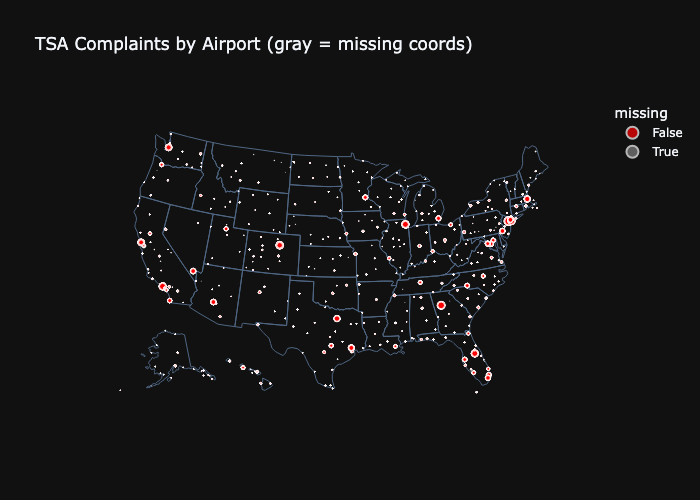

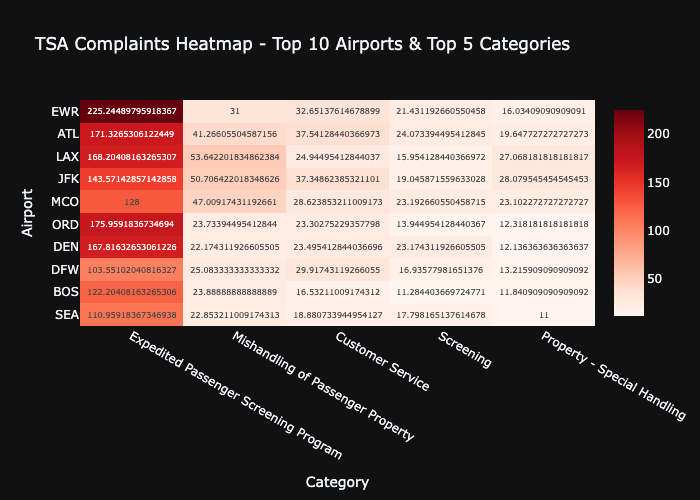

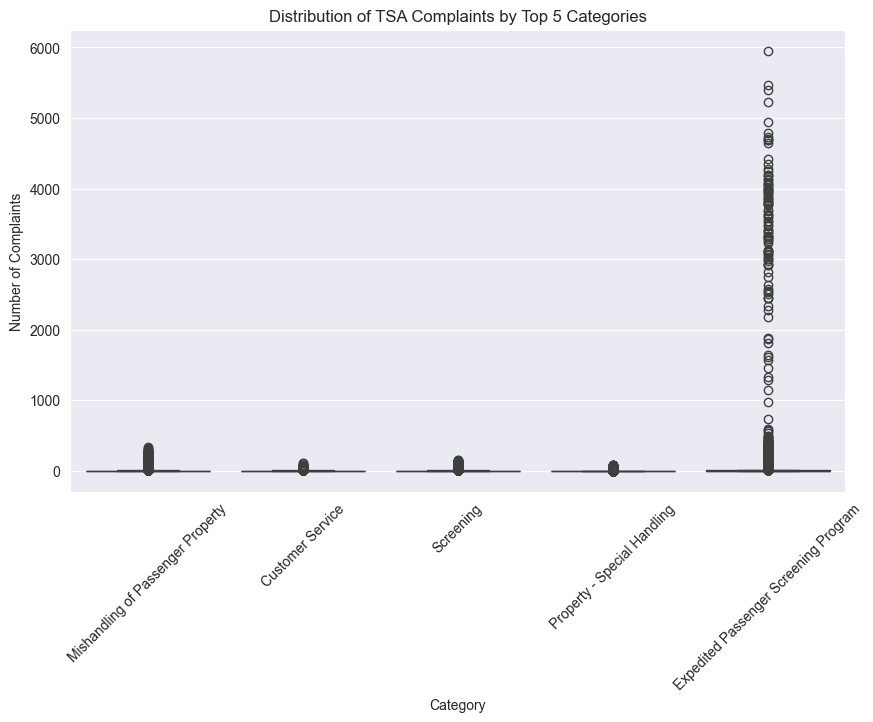

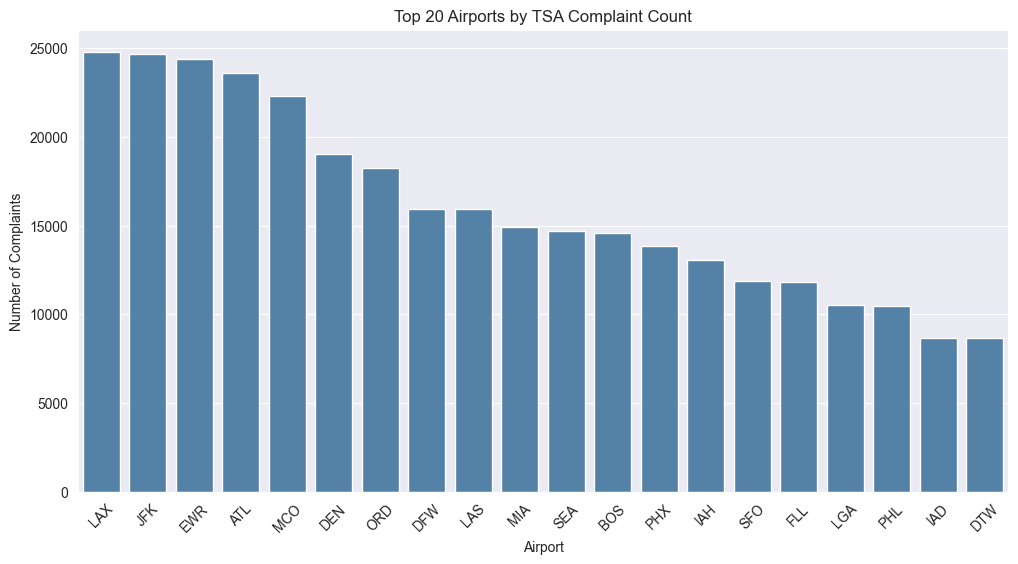

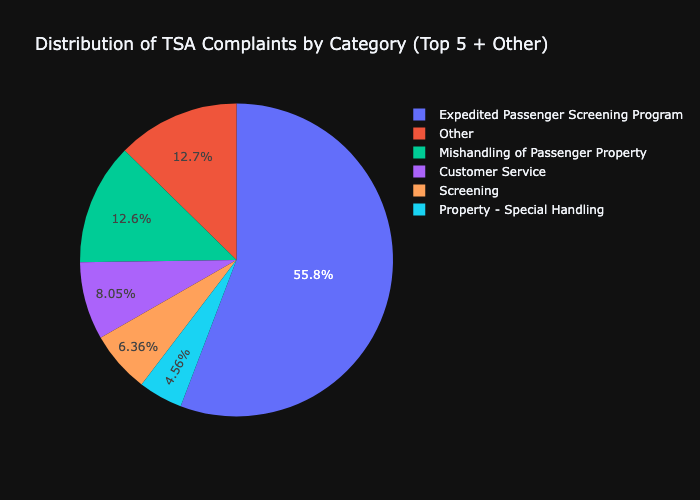

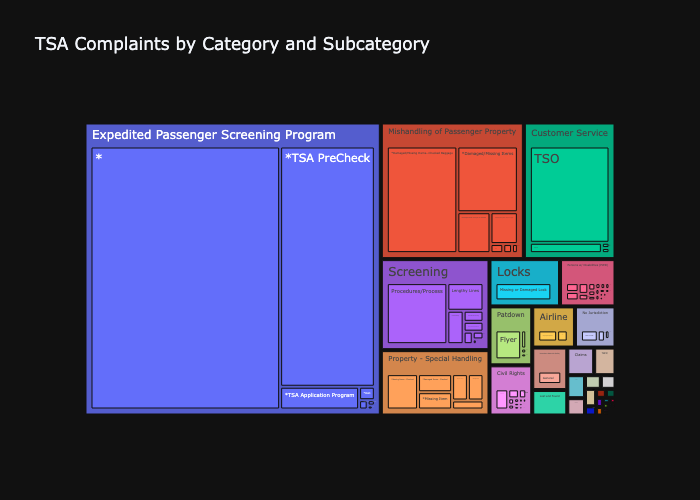

In [40]:
# Assignment 9/10 - TSA Complaints, Megan Pokal, DSC 640

# Import Libraries
import pandas as pd
import plotly.express as px
import plotly.io as pio
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go

# Enable Plotly static image rendering
pio.renderers.default = "png"

# Load datasets
complaints_airport = pd.read_csv("/complaints_by_airport.csv")
complaints_category = pd.read_csv("/complaints_by_category.csv")
complaints_subcategory = pd.read_csv("/complaints_by_subcategory.csv")
iata = pd.read_csv("/iata_icao.csv")

# Combine datasets
# Merge airport coordinates (keep all airports)
airport_data = complaints_airport.merge(
    iata[['iata', 'latitude', 'longitude']],
    left_on='airport',
    right_on='iata',
    how='left'
)

# Mark missing coordinates and fill for plotting
airport_data['missing'] = airport_data['latitude'].isnull()
airport_data.loc[airport_data['missing'], ['latitude', 'longitude']] = 0
airport_data['count'] = airport_data['count'].fillna(0)


# Graph 1: Spatial / Choropleth Map
fig_map = px.scatter_geo(
    airport_data,
    lat='latitude',
    lon='longitude',
    hover_name='airport',
    size='count',
    color='missing',
    color_discrete_map={False: 'red', True: 'gray'},
    scope='usa',
    title='TSA Complaints by Airport (gray = missing coords)'
)
fig_map.show()

# Graph 2: Heat Map - Airports & Categories
# Top 10 Airports
# Pivot table: complaints by airport and category
heat_data = complaints_category.pivot_table(
    index='airport',
    columns='clean_cat',
    values='count',
    fill_value=0
)

# Keep top 5 categories
top_n_categories = heat_data.sum(axis=0).sort_values(ascending=False).head(5).index
heat_data_top = heat_data[top_n_categories]

# Keep top 10 airports
top_n_airports = heat_data_top.sum(axis=1).sort_values(ascending=False).head(10).index
heat_data_top = heat_data_top.loc[top_n_airports]

# Plot heatmap using graph_objects
fig_heat = go.Figure(data=go.Heatmap(
    z=heat_data_top.values,
    x=heat_data_top.columns,
    y=heat_data_top.index,
    colorscale='Reds',
    text=heat_data_top.values,
    texttemplate="%{text}",
    hovertemplate='Airport: %{y}<br>Category: %{x}<br>Complaints: %{z}<extra></extra>'
))

fig_heat.update_layout(
    title=f"TSA Complaints Heatmap - Top 10 Airports & Top 5 Categories",
    xaxis_title="Category",
    yaxis_title="Airport",
    yaxis=dict(autorange="reversed")  # so highest complaints on top
)

fig_heat.show()

# Graph 3: Boxplot - Complaints by Category
# Get top 5 categories by total complaints
top_categories = complaints_category.groupby('clean_cat')['count'].sum().sort_values(ascending=False).head(5).index

# Filter the data
filtered_data = complaints_category[complaints_category['clean_cat'].isin(top_categories)]

# Plot
plt.figure(figsize=(10,6))
sns.boxplot(
    x='clean_cat',
    y='count',
    data=filtered_data
)
plt.title('Distribution of TSA Complaints by Top 5 Categories')
plt.xticks(rotation=45)
plt.ylabel('Number of Complaints')
plt.xlabel('Category')
plt.show()

# Graph 4: Boxplot - Top 20 Airports by Complaint Count
top_airports = complaints_airport.groupby('airport')['count'].sum().sort_values(ascending=False).head(20)
plt.figure(figsize=(12,6))
sns.barplot(
    x=top_airports.index,
    y=top_airports.values,
    color='steelblue'
)
plt.title('Top 20 Airports by TSA Complaint Count')
plt.xticks(rotation=45)
plt.ylabel('Number of Complaints')
plt.xlabel('Airport')
plt.show()

# Graph 5: Pie Chart - Complaints Distribution by Category
# Calculate total complaints per category
category_totals = complaints_category.groupby('clean_cat')['count'].sum().sort_values(ascending=False)

# Keep top 5 categories, group the rest as 'Other'
top_n = 5
top_categories = category_totals.head(top_n)
other_total = category_totals[top_n:].sum()

# Combine top categories with 'Other' using pd.concat
pie_data = pd.concat([top_categories, pd.Series({'Other': other_total})])

# Plot
fig_pie = px.pie(
    names=pie_data.index,
    values=pie_data.values,
    title=f'Distribution of TSA Complaints by Category (Top {top_n} + Other)'
)
fig_pie.show()


# Graph 6: Treemap - Subcategory Complaints
subcategory_counts = complaints_subcategory.groupby(['clean_cat','clean_subcat'])['count'].sum().reset_index()
fig_treemap = px.treemap(
    subcategory_counts,
    path=['clean_cat', 'clean_subcat'],
    values='count',
    title='TSA Complaints by Category and Subcategory'
)
fig_treemap.show()